#Building a CNN Model for Image Classification

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

1. DOWNLOAD DATASET

In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
base_path = path # Adjusting to your notebook's logic
train_dir = os.path.join(base_path, 'seg_train/seg_train')
test_dir = os.path.join(base_path, 'seg_test/seg_test')

Using Colab cache for faster access to the 'intel-image-classification' dataset.


2. PREPROCESSING

In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


3. MODEL ARCHITECTURE

In [4]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


4. TRAINING

In [5]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.5314 - loss: 1.2033 - val_accuracy: 0.6572 - val_loss: 0.8801
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 603s 2s/step - accuracy: 0.6366 - loss: 0.9743 - val_accuracy: 0.6522 - val_loss: 0.8949
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - accuracy: 0.6784 - loss: 0.8681 - val_accuracy: 0.6130 - val_loss: 1.1928
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.7038 - loss: 0.8110 - val_accuracy: 0.7830 - val_loss: 0.6094
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - accuracy: 0.7298 - loss: 0.7507 - val_accuracy: 0.7897 - val_loss: 0.5921
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.7425 - loss: 0.7121 - val_accuracy: 0.7951 - val_loss: 0.5676
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - accuracy: 0.7590 - loss: 0.6899 - val_accuracy: 0.7313 - val_loss: 0.7008
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.7636 - loss: 0.6647 - val_accu

 5. FINAL EVALUATION & METRICS

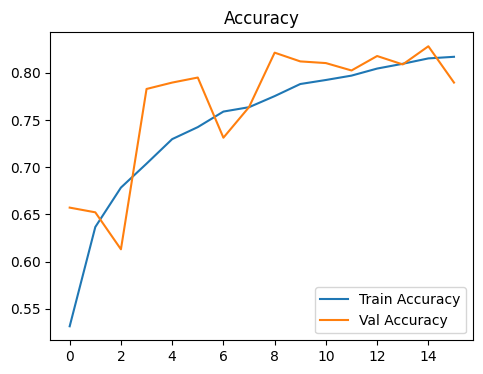

In [6]:
# A. Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

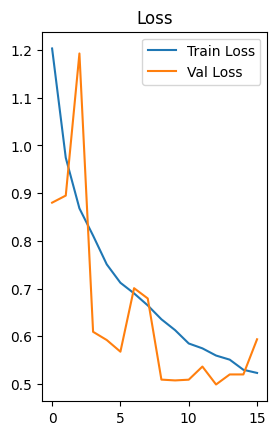

In [7]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [8]:
# B. Predictions for Report & Matrix
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
y_true = []
y_pred = []

Found 3000 files belonging to 6 classes.
